In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plot import make_theme

%matplotlib inline
plt.rcParams['font.size'] = 7

In [2]:
def plot_label(ax, count, x=0, y=1.03, color='k'):
    ax.text(x, y, count, fontdict=dict(fontsize=9), transform=ax.transAxes, color=color, weight='bold')

(0.0, 0.25)

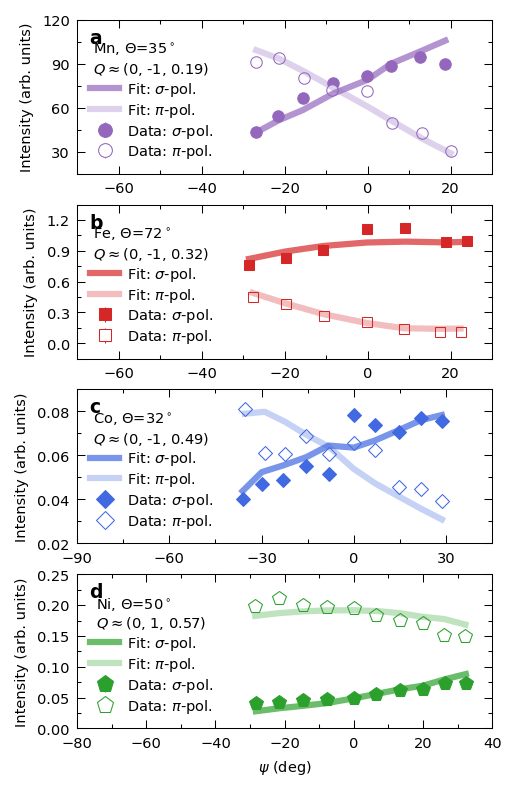

In [3]:
fig, axs = plt.subplots(4, 1, figsize=(6.75/2,6.75/1.3), dpi=150, gridspec_kw=dict(hspace=0.2, left=0.15, right=0.97, top=0.98, bottom=0.07))

edges = ['Mn', 'Fe', 'Co', 'Ni']
colors = ['C4','C3','royalblue','C2']
fmts = ['o', 's', 'D', 'p']
mkss = [5.5,5,5,7]
counts = ['a', 'b', 'c', 'd']
plot_params = dict(ls='none', elinewidth=0.5, mew=0.5)
for edge, color, fmt, mks, count, ax in zip(edges, colors, fmts, mkss, counts, axs):
    data = dict(np.load('../13-3/data/az_'+edge+'_sigma.npz'))
    ax.errorbar(data['psi'], data['I'], data['Ierr'], label=r'Data: $\sigma$-pol.', fmt=fmt, ms=mks, color=color, **plot_params, zorder=-10)
    ax.plot(data['psi'], data['I_calc']*data['scale'], label=r'Fit: $\sigma$-pol.', ls='-', color=color, lw=3, alpha=0.7, zorder=10)
    data = dict(np.load('../13-3/data/az_'+edge+'_pi.npz'))
    ax.errorbar(data['psi'], data['I'], data['Ierr'], label=r'Data: $\pi$-pol.', fmt=fmt, ms=mks, color=color, mfc='w', **plot_params, zorder=-9)
    ax.plot(data['psi'], data['I_calc']*data['scale'], label=r'Fit: $\pi$-pol.', ls='-', color=color, lw=3, alpha=0.3, zorder=11)
    plot_label(ax, count, x=0.03, y=0.85)
    make_theme(ax, ticklength=4)
    ax.legend(title='{}, $\\Theta$={:.0f}$^\\circ$\n$Q\\approx${}'.format(edge,data['omega'],data['Q']), frameon=False, loc='lower left',
              markerscale=1.2, handletextpad=0.5, labelspacing=0.2)
    ax.set_ylabel('Intensity (arb. units)')

axs[-1].set_xlabel('$\\psi$ (deg)')
axs[0].set_xlim(-70,30)
axs[0].set_xticks(np.arange(-60,30,20.))
axs[0].set_ylim(15,120)
axs[0].set_yticks(np.arange(30.,120.1,30.))
axs[1].set_xlim(-70,30)
axs[1].set_xticks(np.arange(-60,30,20.))
axs[1].set_ylim(-0.15,1.35)
axs[1].set_yticks(np.arange(0.,1.21,0.3))
axs[2].set_xlim(-90,45)
axs[2].set_xticks(np.arange(-90,45,30.))
axs[2].set_ylim(0.02,0.09)
axs[2].set_yticks(np.arange(0.02,0.081,0.02))
axs[3].set_xlim(-80,40)
axs[3].set_xticks(np.arange(-80,40.1,20.))
axs[3].set_ylim(0.,0.25)

# fig.savefig('azimuth.pdf')

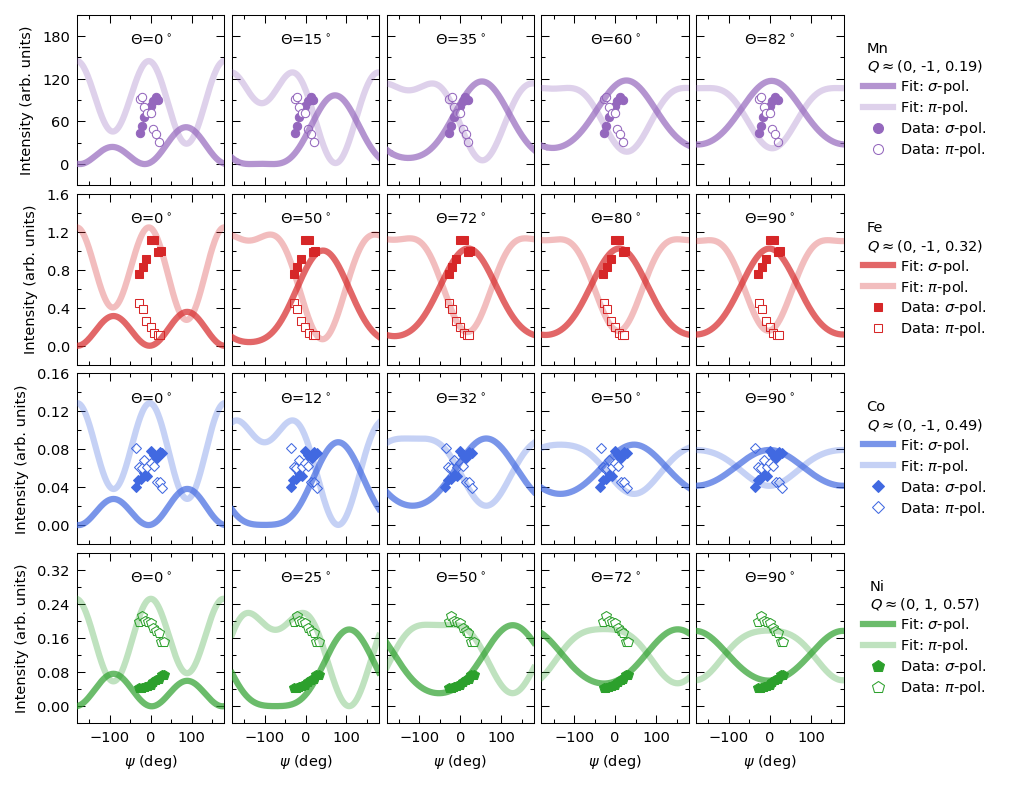

In [4]:
fig, axss = plt.subplots(4, 6, figsize=(6.75,6.75/1.3), sharex=True, sharey='row', dpi=150, gridspec_kw=dict(hspace=0.05, wspace=0.05,
    left=0.07, right=0.98, top=0.98, bottom=0.07))
edges = ['Mn', 'Fe', 'Co', 'Ni']
colors = ['C4','C3','royalblue','C2']
fmts = ['o', 's', 'D', 'p']
mkss = [4,3.5,3.5,5]
Thetass = [[0,15,35,60,82], [0,50,72,80,90], [0,12,32,50,90], [0,25,50,72,90]]
plot_params = dict(ls='none', elinewidth=0.5, mew=0.5)
for edge, color, fmt, mks, axs, Thetas in zip(edges, colors, fmts, mkss, axss, Thetass):
    data1 = dict(np.load('../13-3/data/az_'+edge+'_sigma.npz'))
    data2 = dict(np.load('../13-3/data/az_'+edge+'_pi.npz'))
    axs[-1].errorbar(np.nan, np.nan, label=r'Data: $\sigma$-pol.', fmt=fmt, ms=mks, color=color, **plot_params, zorder=-10)
    axs[-1].errorbar(np.nan, np.nan, label=r'Data: $\pi$-pol.', fmt=fmt, ms=mks, color=color, mfc='w', **plot_params, zorder=-9)
    axs[-1].plot(np.nan, np.nan, label=r'Fit: $\sigma$-pol.', ls='-', color=color, lw=3, alpha=0.7, zorder=10)
    axs[-1].plot(np.nan, np.nan, label=r'Fit: $\pi$-pol.', ls='-', color=color, lw=3, alpha=0.3, zorder=11)
    axs[-1].legend(title='{}\n$Q\\approx${}'.format(edge,data1['Q']), frameon=False, loc='center',
                  markerscale=1.2, handletextpad=0.5, labelspacing=0.2)
    for ax, Theta in zip(axs[:-1], Thetas):
        make_theme(ax, ticklength=4)
        calc1 = dict(np.load('../13-3/data/az_'+edge+'_sigma_{:.0f}.npz'.format(Theta)))
        calc2 = dict(np.load('../13-3/data/az_'+edge+'_pi_{:.0f}.npz'.format(Theta)))
        scale = np.mean(np.hstack([data1['I'], data2['I']])) / np.mean(np.hstack([np.interp(data1['psi'], calc1['psi'], calc1['I_calc']), np.interp(data2['psi'], calc2['psi'], calc2['I_calc'])]))
        # if Theta<20:
        #     if edge=='Ni' or edge=='Co':
        #         scale = np.mean(data2['I']/ np.interp(data2['psi'], calc2['psi'], calc2['I_calc']))
        ax.errorbar(data1['psi'], data1['I'], data1['Ierr'], label=r'Data: $\sigma$-pol.', fmt=fmt, ms=mks, color=color, **plot_params, zorder=-10)
        ax.errorbar(data2['psi'], data2['I'], data2['Ierr'], label=r'Data: $\pi$-pol.', fmt=fmt, ms=mks, color=color, mfc='w', **plot_params, zorder=-9)
        ax.plot(calc1['psi'], calc1['I_calc']*scale, label=r'Fit: $\sigma$-pol.', ls='-', color=color, lw=3, alpha=0.7, zorder=10)
        ax.plot(calc2['psi'], calc2['I_calc']*scale, label=r'Fit: $\pi$-pol.', ls='-', color=color, lw=3, alpha=0.3, zorder=11)
        ax.text(0.5, 0.85, '$\\Theta$={:.0f}$^\\circ$'.format(Theta), fontdict=dict(fontsize=7),
                transform=ax.transAxes, horizontalalignment='center', verticalalignment='center')

axss[0,0].set_xlim(-180,180)
axss[0,0].set_ylim(-30,210)
axss[0,0].set_yticks(np.arange(0.,210.1,60.))
axss[1,0].set_ylim(-0.2,1.6)
axss[1,0].set_yticks(np.arange(0.,1.61,0.4))
axss[2,0].set_ylim(-0.02,0.16)
axss[2,0].set_yticks(np.arange(0.,0.161,0.04))
axss[3,0].set_ylim(-0.04,0.36)
axss[3,0].set_yticks(np.arange(0.,0.361,0.08))
for ax in axss[-1,:-1]:
    ax.set_xlabel('$\\psi$ (deg)')
for ax in axss[:,0]:
    ax.set_ylabel('Intensity (arb. units)')
for ax in axss[:,-1]:
    ax.axis('off')

# fig.savefig('azimuth2.pdf')